In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              confusion_matrix, f1_score,
                              classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
DATASET_PATH = Path(r"C:\Users\jessi\OneDrive\Desktop\aiims2")

df = pd.read_csv(DATASET_PATH / 'features_combined.csv')

# Binary classification: benign vs malignant only
df = df[df['label'].isin(['benign', 'malignant'])].copy()
df['target'] = (df['label'] == 'malignant').astype(int)  # 1=malignant, 0=benign

print(f"Total cases: {len(df)}")
print(df['label'].value_counts())

Total cases: 647
label
benign       437
malignant    210
Name: count, dtype: int64


In [4]:


# Drop non-feature columns
DROP_COLS = ['case_id', 'label', 'target']
feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].fillna(0).values
y = df['target'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Positive (malignant): {y.sum()} | Negative (benign): {(1-y).sum()}")

# Train/test split — stratified so both classes are balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for SVM, LR, MLP
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Feature matrix shape: (647, 3204)
Positive (malignant): 210 | Negative (benign): 437
Train size: 517 | Test size: 130


In [5]:
classifiers = {
    'Random Forest'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'           : XGBClassifier(n_estimators=200, random_state=42,
                                         use_label_encoder=False,
                                         eval_metric='logloss', verbosity=0),
    'LightGBM'          : LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'               : SVC(kernel='rbf', probability=True, random_state=42),
    'MLP'               : MLPClassifier(hidden_layer_sizes=(256, 128),
                                        max_iter=500, random_state=42),
}

In [11]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'auc'        : round(roc_auc_score(y_te, y_prob), 4),
        'accuracy'   : round(accuracy_score(y_te, y_pred), 4),
        'sensitivity': round(tp / (tp + fn) if (tp+fn) > 0 else 0, 4),
        'specificity': round(tn / (tn + fp) if (tn+fp) > 0 else 0, 4),
        'f1'         : round(f1_score(y_te, y_pred), 4),
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

results = {}
for name, clf in classifiers.items():
    print(f"Training {name}...")
    results[name] = evaluate(clf, X_train, y_train, X_test, y_test)

print("\nDone!")

Training Random Forest...
Training XGBoost...
Training LightGBM...


C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Logistic Regression...
Training SVM...
Training MLP...

Done!


In [12]:
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('auc', ascending=False)
print(df_results[['auc', 'accuracy', 'sensitivity', 'specificity', 'f1']])

                        auc  accuracy  sensitivity  specificity      f1
Logistic Regression  0.9619    0.9077       0.8333       0.9432  0.8537
MLP                  0.9600    0.9000       0.8333       0.9318  0.8434
LightGBM             0.9483    0.8846       0.7857       0.9318  0.8148
SVM                  0.9481    0.9000       0.8095       0.9432  0.8395
XGBoost              0.9375    0.8769       0.8095       0.9091  0.8095
Random Forest        0.9349    0.8846       0.8095       0.9205  0.8193


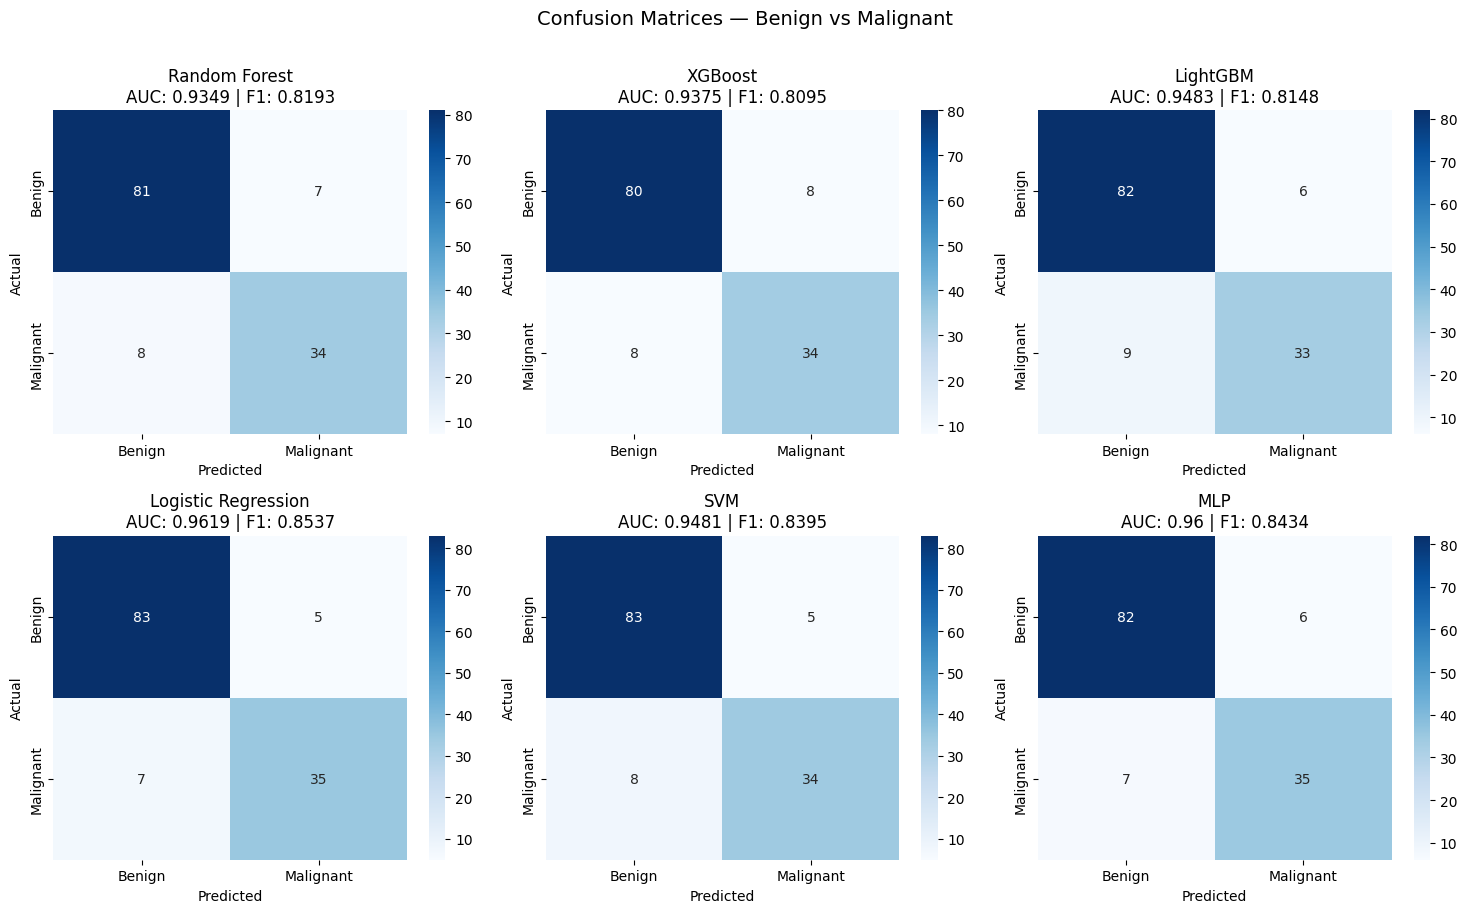

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = np.array([[res['tn'], res['fp']],
                   [res['fn'], res['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    axes[i].set_title(f"{name}\nAUC: {res['auc']} | F1: {res['f1']}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Benign vs Malignant', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
df_results.to_csv(DATASET_PATH / 'results.csv')
print(f"Saved results.csv")
print(f"\nBest model: {df_results['auc'].idxmax()} "
      f"with AUC = {df_results['auc'].max()}")

Saved results.csv

Best model: Logistic Regression with AUC = 0.9619


In [18]:
# re-extract y_prob from the best model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

best_model = clone(classifiers['Logistic Regression'])
best_model.fit(X_train, y_train)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ── 1. shuffled label test ──────────────────────────────────────
y_shuffled = y_test.copy()
np.random.shuffle(y_shuffled)
print('Real AUC:    ', round(roc_auc_score(y_test,    y_prob), 4))
print('Shuffled AUC:', round(roc_auc_score(y_shuffled, y_prob), 4))
print()

# ── 2. train vs test gap ────────────────────────────────────────
y_prob_train = best_model.predict_proba(X_train)[:, 1]
print('Train AUC:', round(roc_auc_score(y_train, y_prob_train), 4))
print('Test AUC: ', round(roc_auc_score(y_test,  y_prob), 4))
print()

# ── 3. cross-val stability ──────────────────────────────────────
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clone(classifiers['Logistic Regression']),
                         X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print('CV folds:', np.round(scores, 4))
print('Mean:', round(scores.mean(), 4), ' Std:', round(scores.std(), 4))


Real AUC:     0.9619
Shuffled AUC: 0.4732

Train AUC: 1.0
Test AUC:  0.9619

CV folds: [0.9471 0.9702 0.939  0.9831 0.9663]
Mean: 0.9611  Std: 0.016


In [21]:
# fast version — use model coefficients directly (works for Logistic Regression)
imp = pd.Series(
    np.abs(best_model.coef_[0]),
    index=feature_cols
).sort_values(ascending=False)

print('Top 20 features driving AUC:')
print(imp.head(20))

Top 20 features driving AUC:
lbp_3_ring_15px      0.128809
tumor_180            0.108304
posterior_722        0.106381
lbp_7_ring_15px      0.105578
tumor_93             0.105124
whole_147            0.104986
whole_153            0.104903
perilesion_754       0.101123
posterior_526        0.100627
perilesion_632       0.100454
whole_326            0.100190
posterior_458        0.098993
posterior_585        0.098247
whole_427            0.098138
tumor_28             0.097392
posterior_35         0.097123
whole_389            0.096027
skewness_ring_5px    0.095805
whole_423            0.095096
tumor_190            0.094798
dtype: float64


In [22]:
# find where deep embedding columns start
texture_cols = [c for c in feature_cols if not c.startswith('emb_') and not 'embedding' in c.lower()]
deep_cols    = [c for c in feature_cols if c not in texture_cols]

print(f'Texture features: {len(texture_cols)}')
print(f'Deep embedding features: {len(deep_cols)}')

X_texture = df[texture_cols].fillna(0).values
X_deep    = df[deep_cols].fillna(0).values

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

for name, X_subset in [('Texture only', X_texture), ('Deep only', X_deep), ('Combined', X)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_subset, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    cv  = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                          X_tr, y_tr, cv=5, scoring='roc_auc').mean()
    print(f'{name:20s}  Test AUC: {auc:.4f}  CV AUC: {cv:.4f}')

Texture features: 3204
Deep embedding features: 0
Texture only          Test AUC: 0.9619  CV AUC: 0.9611


ValueError: Found array with 0 feature(s) (shape=(517, 0)) while a minimum of 1 is required by StandardScaler.

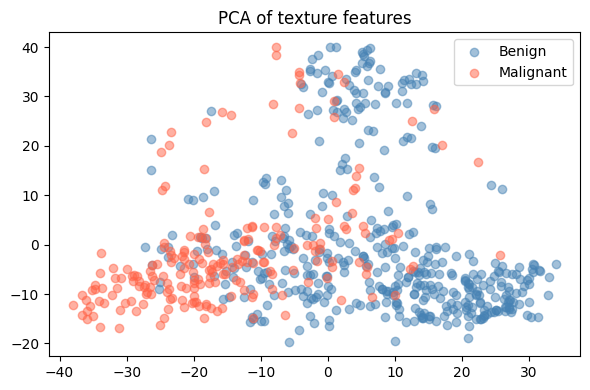

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(6,4))
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], alpha=0.5, label='Benign',    color='steelblue')
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], alpha=0.5, label='Malignant', color='tomato')
plt.legend()
plt.title('PCA of texture features')
plt.tight_layout()
plt.show()

In [24]:
# check how many unique patients / cases
print('Total cases:', len(df))
print('Malignant:  ', (y==1).sum())
print('Benign:     ', (y==0).sum())
print()
# check if case_ids look like a known dataset
print(df['case_id'].head(10))

Total cases: 647
Malignant:   210
Benign:      437

0      benign (1)
1     benign (10)
2    benign (100)
3    benign (101)
4    benign (102)
5    benign (103)
6    benign (104)
7    benign (105)
8    benign (106)
9    benign (107)
Name: case_id, dtype: object


In [25]:
print(df.columns.tolist()[:30])

['case_id', 'label', 'edge_density_background', 'edge_density_posterior', 'edge_density_ring_15px', 'edge_density_ring_5px', 'edge_density_skin', 'edge_density_tumor', 'entropy_background', 'entropy_posterior', 'entropy_ring_15px', 'entropy_ring_5px', 'entropy_skin', 'entropy_tumor', 'glcm_contrast_background', 'glcm_contrast_posterior', 'glcm_contrast_ring_15px', 'glcm_contrast_ring_5px', 'glcm_contrast_skin', 'glcm_contrast_tumor', 'glcm_correlation_background', 'glcm_correlation_posterior', 'glcm_correlation_ring_15px', 'glcm_correlation_ring_5px', 'glcm_correlation_skin', 'glcm_correlation_tumor', 'glcm_energy_background', 'glcm_energy_posterior', 'glcm_energy_ring_15px', 'glcm_energy_ring_5px']


In [26]:
deep_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')
print(deep_df.shape)
print(deep_df.columns.tolist()[:10])
print(deep_df.head(2))

(780, 3074)
['case_id', 'label', 'tumor_0', 'tumor_1', 'tumor_2', 'tumor_3', 'tumor_4', 'tumor_5', 'tumor_6', 'tumor_7']
       case_id   label   tumor_0   tumor_1   tumor_2   tumor_3   tumor_4  \
0   benign (1)  benign -0.140227  0.199341  0.014288 -0.093048  0.300193   
1  benign (10)  benign -0.004000  0.183299 -0.220773  0.085275  0.018301   

    tumor_5   tumor_6   tumor_7  ...  whole_758  whole_759  whole_760  \
0 -0.061440 -0.245403  0.049486  ...  -0.056358  -0.106251  -0.021558   
1 -0.010775 -0.196513 -0.021403  ...  -0.161345   0.008025   0.132144   

   whole_761  whole_762  whole_763  whole_764  whole_765  whole_766  whole_767  
0   0.098186   0.071740   0.034187   0.023795  -0.224141   0.102715  -0.009094  
1   0.061322  -0.013692   0.085919  -0.138765  -0.025004   0.123716   0.132169  

[2 rows x 3074 columns]


In [27]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
deep_df    = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')

# drop normal from deep too
deep_df = deep_df[deep_df['label'].isin(['benign', 'malignant'])].copy()

print('Texture rows:', len(texture_df))
print('Deep rows:   ', len(deep_df))

# merge on case_id
combined = pd.merge(texture_df, deep_df.drop(columns=['label']), on='case_id', how='inner')

print('Combined rows:   ', len(combined))
print('Combined columns:', combined.shape[1])

# save
combined.to_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv', index=False)
print('Saved features_combined.csv')

Texture rows: 4148
Deep rows:    647
Combined rows:    3882
Combined columns: 3097
Saved features_combined.csv


In [28]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
print(texture_df.shape)
print(texture_df.head(5)[['case_id', 'label']]) 
print(texture_df['case_id'].value_counts().head(10))

(4148, 25)
      case_id   label
0  benign (1)  benign
1  benign (1)  benign
2  benign (1)  benign
3  benign (1)  benign
4  benign (1)  benign
case_id
benign (1)      6
benign (10)     6
benign (100)    6
benign (101)    6
benign (102)    6
benign (103)    6
benign (104)    6
benign (105)    6
benign (106)    6
benign (107)    6
Name: count, dtype: int64


In [30]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
deep_df    = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')

# check what the region column is called
print(texture_df.columns.tolist())

['case_id', 'label', 'region', 'mean_intensity', 'std_intensity', 'skewness', 'kurtosis', 'entropy', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9', 'edge_density', 'shadow_index', 'lesion_background_contrast']


In [31]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
deep_df    = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')

# pivot texture: one row per case, columns become region_feature
feature_cols = ['mean_intensity', 'std_intensity', 'skewness', 'kurtosis', 'entropy',
                'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
                'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7',
                'lbp_8', 'lbp_9', 'edge_density', 'shadow_index', 'lesion_background_contrast']

texture_wide = texture_df.pivot_table(
    index=['case_id', 'label'],
    columns='region',
    values=feature_cols
)

# flatten column names: feature_region
texture_wide.columns = [f'{feat}_{reg}' for feat, reg in texture_wide.columns]
texture_wide = texture_wide.reset_index()

print('Texture wide shape:', texture_wide.shape)

# drop normal from deep
deep_df = deep_df[deep_df['label'].isin(['benign', 'malignant'])].copy()

# merge
combined = pd.merge(texture_wide, deep_df.drop(columns=['label']), on='case_id', how='inner')
print('Combined shape:', combined.shape)

# save both
texture_wide.to_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv', index=False)
combined.to_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv', index=False)
print('Saved both CSVs')

Texture wide shape: (780, 134)
Combined shape: (647, 3206)
Saved both CSVs


In [32]:
df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv')

df = df[df['label'].isin(['benign', 'malignant'])].copy()
df['target'] = (df['label'] == 'malignant').astype(int)

DROP_COLS = ['case_id', 'label', 'target']
feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].fillna(0).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Features: {X.shape[1]}  Train: {len(X_train)}  Test: {len(X_test)}')

for name, clf in classifiers.items():
    clf_fresh = clone(clf)
    clf_fresh.fit(X_train, y_train)
    y_prob = clf_fresh.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f'{name:22s}  AUC: {round(auc, 4)}')

Features: 3204  Train: 517  Test: 130
Random Forest           AUC: 0.9349
XGBoost                 AUC: 0.9375


C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                AUC: 0.9483
Logistic Regression     AUC: 0.9619
SVM                     AUC: 0.9481
MLP                     AUC: 0.96


In [33]:
df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv')
print(df.shape)
print(df.columns.tolist()[-10:])  # last 10 columns — should be embedding columns

(647, 3206)
['whole_758', 'whole_759', 'whole_760', 'whole_761', 'whole_762', 'whole_763', 'whole_764', 'whole_765', 'whole_766', 'whole_767']


In [34]:
df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv')
df = df[df['label'].isin(['benign', 'malignant'])].copy()
df['target'] = (df['label'] == 'malignant').astype(int)

DROP_COLS = ['case_id', 'label', 'target']
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].fillna(0).values
y = df['target'].values
print('X shape:', X.shape)

X shape: (647, 3204)


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (517, 3204) Test: (130, 3204)


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

classifiers_new = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=200, eval_metric='logloss', verbosity=0, random_state=42),
    'LightGBM'           : LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
    'MLP'                : MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
}

for name, clf in classifiers_new.items():
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f'{name:22s}  AUC: {round(auc, 4)}')

Random Forest           AUC: 0.9349
XGBoost                 AUC: 0.9375


C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                AUC: 0.9483
Logistic Regression     AUC: 0.9619
SVM                     AUC: 0.9481
MLP                     AUC: 0.96


In [37]:
print('Total columns in CSV:', df.shape[1])
print('DROP_COLS found:', [c for c in DROP_COLS if c in df.columns])
print('Feature cols count:', len(feature_cols))

# check if embedding columns are in feature_cols
emb_cols = [c for c in feature_cols if c.startswith('tumor_') or c.startswith('whole_')]
print('Embedding cols in X:', len(emb_cols))
print('Sample embedding cols:', emb_cols[:5])

Total columns in CSV: 3207
DROP_COLS found: ['case_id', 'label', 'target']
Feature cols count: 3204
Embedding cols in X: 1536
Sample embedding cols: ['tumor_0', 'tumor_1', 'tumor_2', 'tumor_3', 'tumor_4']
